In [1]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact


c:\Users\Raees\Desktop\stuff\NuOscProbExact


fatal: destination path 'NuOscProbExact' already exists and is not an empty directory.


In [2]:
# importing modules used
import numpy as np 
import matplotlib.pyplot as plt
from NuOscProbExact.src import  oscprob2nu, globaldefs
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
import copy as cp

In [3]:

def hamiltonian_vacuum(sth,Dm2): # couldn't import, so just copied it

    th = np.arcsin(sth)
    c2th = math.cos(2.0*th)
    s2th = math.sin(2.0*th)

    f = 1./4.
    # PMNS matrix
    R = np.array(mixing_matrix_2nu(sth))
    # Mass matrix
    M2 = np.array([[Dm2, 0.0], [0.0, -Dm2]])
    # Hamiltonian
    H = list(f*np.matmul(R, np.matmul(M2, np.matrix.transpose(R))))

    return H

def mixing_matrix_2nu(sth):
    cth = math.sqrt(1.0-sth*sth)

    U00 = cth
    U01 = sth
    U10 = -sth
    U11 = cth

    return [[U00,U01],[U10,U11]]

def hamiltonian_2nu_matter(h_vacuum_energy_independent, energy, VCC):

    h_matter = cp.deepcopy(h_vacuum_energy_independent)
    h_matter = np.multiply(1.0/energy, h_matter)

    # Add the matter potential to the ee term to find the matter
    # Hamiltonian
    h_matter[0][0] += VCC

    return h_matter


# Function to calculate oscillation probabilities
def probabilities(hamiltonian, bin_centers, length):
    # lists to store probabilities for each type of oscillation
    Pee_values = []
    Pem_values = []
    Pme_values = []
    Pmm_values = [] 

    for i in bin_centers:
        # calculate probabilities using the `oscprob2nu` module and append to respective lists
        Pee, Pem, Pme, Pmm = oscprob2nu.probabilities_2nu(hamiltonian,length*5.06773e9)
        Pee_values.append(Pee)
        Pem_values.append(Pem)
        Pme_values.append(Pme)
        Pmm_values.append(Pmm)

    return np.array(Pee_values), np.array(Pem_values), np.array(Pme_values), np.array(Pmm_values)

# Function to generate counts from a Poisson distribution based on probabilities and Gaussian scaling    
def poisson_dist(probability, bin_centers):
    counts = np.random.poisson(probability * gaus(bin_centers,amplitude,mean,sigma)) # type: ignore
    return counts

# Gaussian function
def gaus(x,p0,p1,p2):
    return p0 * math.e**((-0.5 * (x - p1)**2)/ p2**2)

In [4]:
from numpy import *  # globaldefs
import numpy as np # wasn't runnning properly, so i just copied it


CONV_KM_TO_INV_EV = 5.06773e9
r"""float: Module-level constant

Multiplicative conversion factor from km to eV^{-1}.
Units: [km^{-1} eV^{-1}].
"""

CONV_CM_TO_INV_EV = CONV_KM_TO_INV_EV*1.e-5
r"""float: Module-level constant

Multiplicative conversion factor from cm to eV^{-1}.
Units: [cm^{-1} eV^{-1}]
"""

CONV_INV_EV_TO_CM = 1./CONV_CM_TO_INV_EV
r"""float: Module-level constant

Multiplicative conversion factor from eV^{-1} to cm.
Units: [eV cm]
"""

CONV_EV_TO_G = 1.783e-33
r"""float: Module-level constant

Multiplicative conversion factor from eV^{-1} to grams.
Units: [g eV^{-1}]
"""

CONV_G_TO_EV = 1./CONV_EV_TO_G
r"""float: Module-level constant

Multiplicative conversion factor from grams to eV^{-1}.
Units: [eV g^{-1}]
"""

GF = 1.1663787e-23
r"""float: Module-level constant

Fermi constant.
Units: [eV^{-1}]
"""

MASS_ELECTRON = 0.5109989461e6
r"""float: Module-level constant

Electron mass.
Units: [eV]
"""

MASS_PROTON = 938.272046e6
r"""float: Module-level constant

Proton mass.
Units: [eV]
"""

MASS_NEUTRON = 939.565379e6
r"""float: Module-level constant

Neutron mass.
Units: [eV]
"""

ELECTRON_FRACTION_EARTH_CRUST = 0.5
r"""float: Module-level constant

Electron fraction in the Earth's crust.
Units: [Adimensional]
"""

DENSITY_MATTER_CRUST_G_PER_CM3 = 3.0
r"""float: Module-level constant

Average matter density in the Earth's crust.
Units: [g cm^{-3}]
"""

# NUM_DENSITY_E_EARTH_CRUST = DENSITY_MATTER_CRUST_G_PER_CM3 * CONV_G_TO_EV \
#                             / ((MASS_PROTON+MASS_NEUTRON)/2.0) \
#                             * ELECTRON_FRACTION_EARTH_CRUST \
#                             / pow(CONV_CM_TO_INV_EV, 3.0)
NUM_DENSITY_E_EARTH_CRUST = DENSITY_MATTER_CRUST_G_PER_CM3 * CONV_G_TO_EV \
                            / ((MASS_PROTON+MASS_NEUTRON)/2.0) \
                            * ELECTRON_FRACTION_EARTH_CRUST \
                            / pow(CONV_CM_TO_INV_EV, 3.0)
r"""float: Module-level constant

Electron number density in the Earth's crust
Units: [eV^3]
"""

VCC_EARTH_CRUST = sqrt(2.0)*GF*NUM_DENSITY_E_EARTH_CRUST
r"""float: Module-level constant

Charged-current matter potential in the Earth's crust.
Units: [eV]
"""

S12_NO_BF = sqrt(0.310)
r"""float: Module-level constant

Lepton mixing angle sin(theta_12), best fit from NuFit 4.0, assuming
normal ordering with SK atmospheric data.
Units: [Adimensional]
"""

S23_NO_BF = sqrt(0.582)
r"""float: Module-level constant

Lepton mixing angle sin(theta_23), best fit from NuFit 4.0, assuming
normal ordering with SK atmospheric data.
Units: [Adimensional]
"""

S13_NO_BF = sqrt(2.240e-2)
r"""float: Module-level constant

Lepton mixing angle sin(theta_13), best fit from NuFit 4.0, assuming
normal ordering with SK atmospheric data.
Units: [Adimensional]
"""

DCP_NO_BF = 217./180.*np.pi
r"""float: Module-level constant

Lepton CP-violation phase delta_CP, best fit from NuFit 4.0, assuming
normal ordering with SK atmospheric data.
Units: [radian]
"""

D21_NO_BF = 7.39e-5
r"""float: Module-level constant

Mass-squared difference Delta m^2_21, best fit from NuFit 4.0, assuming
normal ordering with SK atmospheric data.
Units: [eV^2]
"""

D31_NO_BF = 2.525e-3
r"""float: Module-level constant

Mass-squared difference Delta m^2_31, best fit from NuFit 4.0, assuming
normal ordering with SK atmospheric data.
Units: [eV^2]
"""

S12_IO_BF = sqrt(0.310)
r"""float: Module-level constant

Lepton mixing angle sin(theta_12), best fit from NuFit 4.0, assuming
inverted ordering with SK atmospheric data.
Units: [Adimensional]
"""

S23_IO_BF = sqrt(0.582)
r"""float: Module-level constant

Lepton mixing angle sin(theta_23), best fit from NuFit 4.0, assuming
inverted ordering with SK atmospheric data.
Units: [Adimensional]
"""

S13_IO_BF = sqrt(2.263e-2)
r"""float: Module-level constant

Lepton mixing angle sin(theta_13), best fit from NuFit 4.0, assuming
inverted ordering with SK atmospheric data.
Units: [Adimensional]
"""

DCP_IO_BF = 280./180.*np.pi
r"""float: Module-level constant

Lepton CP-violation phase delta_CP, best fit from NuFit 4.0, assuming
inverted ordering with SK atmospheric data.
Units: [radian]
"""

D21_IO_BF = 7.39e-5
r"""float: Module-level constant

Mass-squared difference Delta m^2_21, best fit from NuFit 4.0, assuming
normal ordering with SK atmospheric data.
Units: [eV^2]
"""

D32_IO_BF = -2.512e-3
r"""float: Module-level constant

Mass-squared difference Delta m^2_32, best fit from NuFit 4.0, assuming
normal ordering with SK atmospheric data.
Units: [eV^2]
"""

D31_IO_BF = D32_IO_BF+D21_IO_BF
r"""float: Module-level constant

Mass-squared difference Delta m^2_31, best fit from NuFit 4.0, assuming
inverted ordering with SK atmospheric data.
Units: [eV^2]
"""

EPS_EE = 0.06
r"""float: Module-level constant

Total NSI strength parameter eps_ee computed using values of the u and d
quark parameters compatible at 2sigma with LMA+coherent from 1805.04530.
Units: [Adimensional]
"""

EPS_EM = -0.06
r"""float: Module-level constant

Total NSI strength parameter eps_em computed using values of the u and d
quark parameters compatible at 2sigma with LMA+coherent from 1805.04530.
Units: [Adimensional]
"""

EPS_ET = 0.0
r"""float: Module-level constant

Total NSI strength parameter eps_et computed using values of the u and d
quark parameters compatible at 2sigma with LMA+coherent from 1805.04530.
Units: [Adimensional]
"""

EPS_MM = 1.2
r"""float: Module-level constant

Total NSI strength parameter eps_mm computed using values of the u and d
quark parameters compatible at 2sigma with LMA+coherent from 1805.04530.
Units: [Adimensional]
"""

EPS_MT = 0.0
r"""float: Module-level constant

Total NSI strength parameter eps_mt computed using values of the u and d
quark parameters compatible at 2sigma with LMA+coherent from 1805.04530.
Units: [Adimensional]
"""

EPS_TT = 0.0
r"""float: Module-level constant

Total NSI strength parameter eps_tt computed using values of the u and d
quark parameters compatible at 2sigma with LMA+coherent from 1805.04530.
Units: [Adimensional]
"""

EPS_2 = [EPS_EE, EPS_EM, EPS_MM]
r"""float: Module-level constant

Vector of total NSI strength parameters for two-neutrino oscillations.
Used in oscprob2nu_plot.py.
Units: [Adimensional]
"""

EPS_3 = [EPS_EE, EPS_EM, EPS_ET, EPS_MM, EPS_MT, EPS_TT]
r"""float: Module-level constant

Vector of total NSI strength parameters for three-neutrino oscillations.
Used in oscprob3nu_plot.py.
Units: [Adimensional]
"""

# LIV parameters
# Compatible with 90% C.L. upper limits on c^(4) from 1709.03434
SXI12 = 0.0
r"""float: Module-level constant

LIV lepton mixing angle sin(xi_12).
Units: [Adimensional]
"""

SXI23 = 0.0
r"""float: Module-level constant

LIV lepton mixing angle sin(xi_23).
Units: [Adimensional]
"""

SXI13 = 0.0
r"""float: Module-level constant

LIV lepton mixing angle sin(xi_13).
Units: [Adimensional]
"""

DXICP = 0.0
r"""float: Module-level constant

LIV CP-violation phase.
Units: [radian]
"""

B1 = 1.e-9
r"""float: Module-level constant

LIV eigenvalue b_1.
Units: [eV]
"""

B2 = 1.e-9
r"""float: Module-level constant

LIV eigenvalue b_2.
Units: [eV]
"""
B3 = 2.e-9
r"""float: Module-level constant

LIV eigenvalue b_3.
Units: [eV]
"""

LAMBDA = 1.e12 # [eV]
r"""float: Module-level constant

LIV energy scale Lambda.
Units: [eV]
"""

'float: Module-level constant\n\nLIV energy scale Lambda.\nUnits: [eV]\n'

In [5]:
# parameters gotten from previous nb
amplitude = 143.9478108222235
mean = 1.8384983482522512
sigma = 0.5273664472026398

# other params
length_nd = 10e-3
length_fd = 1000
events = 1000

# generate random numbers within the range [0, 5] (x-axis)
random_numbers = np.random.normal(mean, sigma, events)
print(f"Generated mean: {np.mean(random_numbers)}, Generated std dev: {np.std(random_numbers)}")

# example
energy = 1.e9
baseline=1.3e3

h_vacuum_energy = hamiltonian_vacuum(math.sqrt(0.582),2.525e-3)
h_vacuum = np.multiply(1./energy, h_vacuum_energy)
h_matter = hamiltonian_2nu_matter(h_vacuum_energy, energy, VCC_EARTH_CRUST)

Pee, Pem, Pme, Pmm = oscprob2nu.probabilities_2nu(h_vacuum, baseline*5.06773e9)

print('\n In vacuum')
print("Pee = %6.5f, Pem = %6.5f" % (Pee, Pem))
print("Pme = %6.5f, Pmm = %6.5f" % (Pme, Pmm))

Pee, Pem, Pme, Pmm = oscprob2nu.probabilities_2nu(h_matter, baseline*5.06773e9)
print('\n In matter')
print("Pee = %6.5f, Pem = %6.5f" % (Pee, Pem))
print("Pme = %6.5f, Pmm = %6.5f" % (Pme, Pmm))

Generated mean: 1.8315422424195908, Generated std dev: 0.5337601829124522

 In vacuum
Pee = 0.29595, Pem = 0.70405
Pme = 0.70405, Pmm = 0.29595

 In matter
Pee = 0.32120, Pem = 0.67880
Pme = 0.67880, Pmm = 0.32120


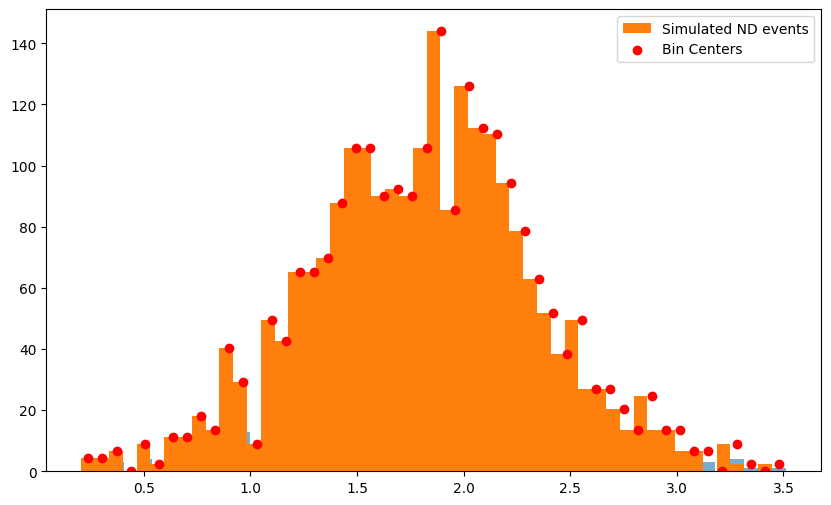

In [6]:
# Simulating ND events from the amplitude, mean and sigma from actual data
plt.figure(figsize=(10,6))
counts, bin_edges, _ = plt.hist(random_numbers, bins=50, alpha=0.6)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#print("Bin centers:", bin_centers)

scaled_counts = counts * (amplitude / max(counts))

plt.hist(bin_edges[:-1], weights=scaled_counts, bins=50, label='Simulated ND events')
plt.scatter(bin_centers, scaled_counts, marker='o', color='red', label='Bin Centers')
plt.legend()
plt.show()

Fitted parameters for simulated ND P(e --> e) events: Amplitude = 14.806152961363491, Mean = 1.846915354091508, Sigma = 0.5211137938047155
Fitted parameters for simulated ND P(e --> m) events: Amplitude = 131.20180291285064, Mean = 1.8120492075511307, Sigma = 0.5485601394540902
Fitted parameters for simulated ND P(e --> m) events: Amplitude = 128.88581737000973, Mean = 1.8133454618557434, Sigma = 0.5281234513310998
Fitted parameters for simulated ND P(m --> m) events: Amplitude = 12.757076609738986, Mean = 1.783495829538134, Sigma = 0.5034294119270729


Parameters of actual data: Amplitude = 143.9478108222235, Mean = 1.8384983482522512, Sigma = 0.5273664472026398 


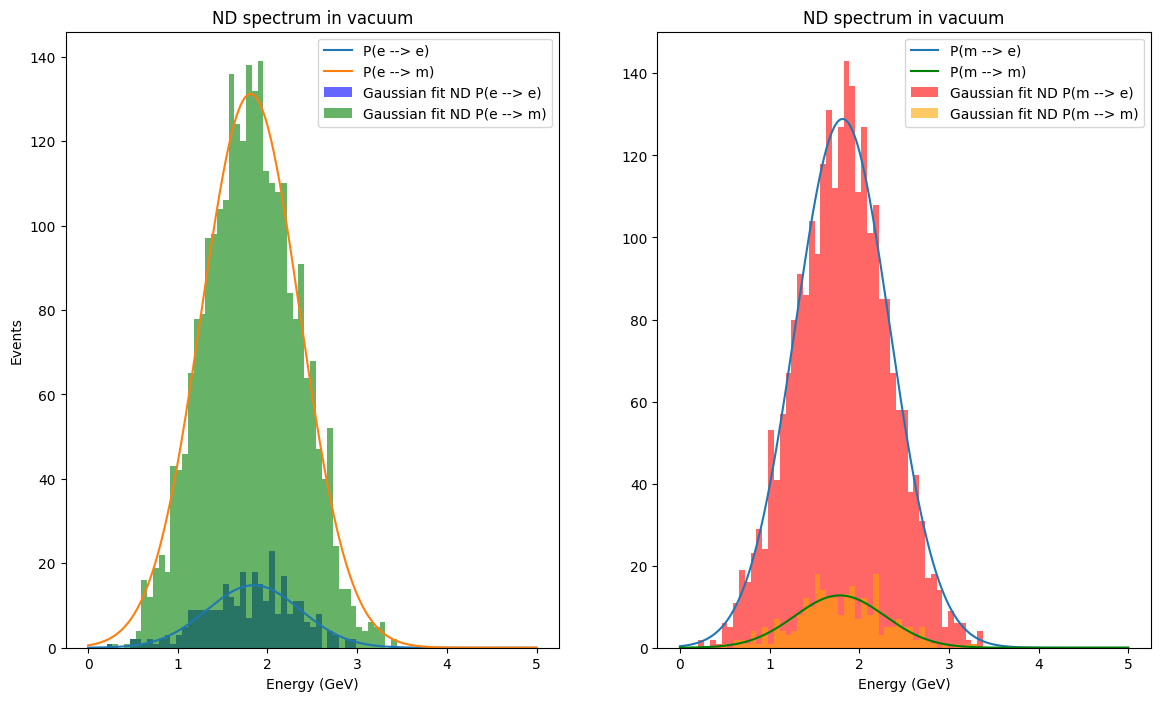

In [7]:
# Calculate oscillation probabilities for each bin center
Pee_vc_nd, Pem_vc_nd, Pme_vc_nd, Pmm_vc_nd = probabilities(h_vacuum, bin_centers,length_nd *5.06773e9)

# Generate event counts for each transition type based on probabilities
counts_Pee_vc_nd = poisson_dist(Pee_vc_nd,bin_centers)
counts_Pem_vc_nd = poisson_dist(Pem_vc_nd,bin_centers)
counts_Pme_vc_nd = poisson_dist(Pme_vc_nd,bin_centers)
counts_Pmm_vc_nd = poisson_dist(Pmm_vc_nd,bin_centers)

# Set up Gaussian initial guess for curve fitting
x = np.arange(0,5,0.001)
initial_guess = [140,2,0.5]

# Fit Gaussian curves to each count distribution and print the parameters
popt_Pee_nd, _ = curve_fit(gaus, bin_edges[:-1], counts_Pee_vc_nd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(e --> e) events: Amplitude = {popt_Pee_nd[0]}, Mean = {popt_Pee_nd[1]}, Sigma = {popt_Pee_nd[2]}")

popt_Pem_nd, _ = curve_fit(gaus, bin_edges[:-1], counts_Pem_vc_nd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(e --> m) events: Amplitude = {popt_Pem_nd[0]}, Mean = {popt_Pem_nd[1]}, Sigma = {popt_Pem_nd[2]}")

popt_Pme_nd, _ = curve_fit(gaus, bin_edges[:-1], counts_Pme_vc_nd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(e --> m) events: Amplitude = {popt_Pme_nd[0]}, Mean = {popt_Pme_nd[1]}, Sigma = {popt_Pme_nd[2]}")

popt_Pmm_nd, _ = curve_fit(gaus, bin_edges[:-1], counts_Pmm_vc_nd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(m --> m) events: Amplitude = {popt_Pmm_nd[0]}, Mean = {popt_Pmm_nd[1]}, Sigma = {popt_Pmm_nd[2]}")

print('\n')
print(f'Parameters of actual data: Amplitude = {amplitude}, Mean = {mean}, Sigma = {sigma} ')

# 2x2 grid of subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 8))

# Display histogram of the results
axs[0].hist(bin_edges[:-1], bins=50, weights=counts_Pee_vc_nd, density=False, alpha=0.6, color='b')
axs[0].hist(bin_edges[:-1], bins=50, weights=counts_Pem_vc_nd, density=False, alpha=0.6, color='g')
axs[0].plot(x,gaus(x,*popt_Pee_nd))
axs[0].plot(x,gaus(x,*popt_Pem_nd))
axs[0].set_title("ND spectrum in vacuum")
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")
axs[0].legend(['P(e --> e)','P(e --> m)','Gaussian fit ND P(e --> e)','Gaussian fit ND P(e --> m)'])

axs[1].hist(bin_edges[:-1], bins=50, weights=counts_Pme_vc_nd, density=False, alpha=0.6, color='r')
axs[1].hist(bin_edges[:-1], bins=50, weights=counts_Pmm_vc_nd, density=False, alpha=0.6, color='orange')
axs[1].plot(x,gaus(x,*popt_Pme_nd))
axs[1].plot(x,gaus(x,*popt_Pmm_nd), color='g')
axs[1].set_title("ND spectrum in vacuum")
axs[1].set_xlabel("Energy (GeV)")
axs[1].legend(['P(m --> e)', 'P(m --> m)','Gaussian fit ND P(m --> e)','Gaussian fit ND P(m --> m)'])

Fitted parameters for simulated FD P(e --> e) events: Amplitude = 44.770078947309806, Mean = 1.799762863113641, Sigma = 0.5316613673493831
Fitted parameters for simulated FD P(e --> m) events: Amplitude = 101.82363312329795, Mean = 1.8019689755125106, Sigma = 0.49540946288092014
Fitted parameters for simulated FD P(e --> m) events: Amplitude = 94.18530905255137, Mean = 1.8388713392695248, Sigma = 0.5636151752010667
Fitted parameters for simulated FD P(m --> m) events: Amplitude = 47.87150434517212, Mean = 1.8043963093990725, Sigma = 0.5013112446008107


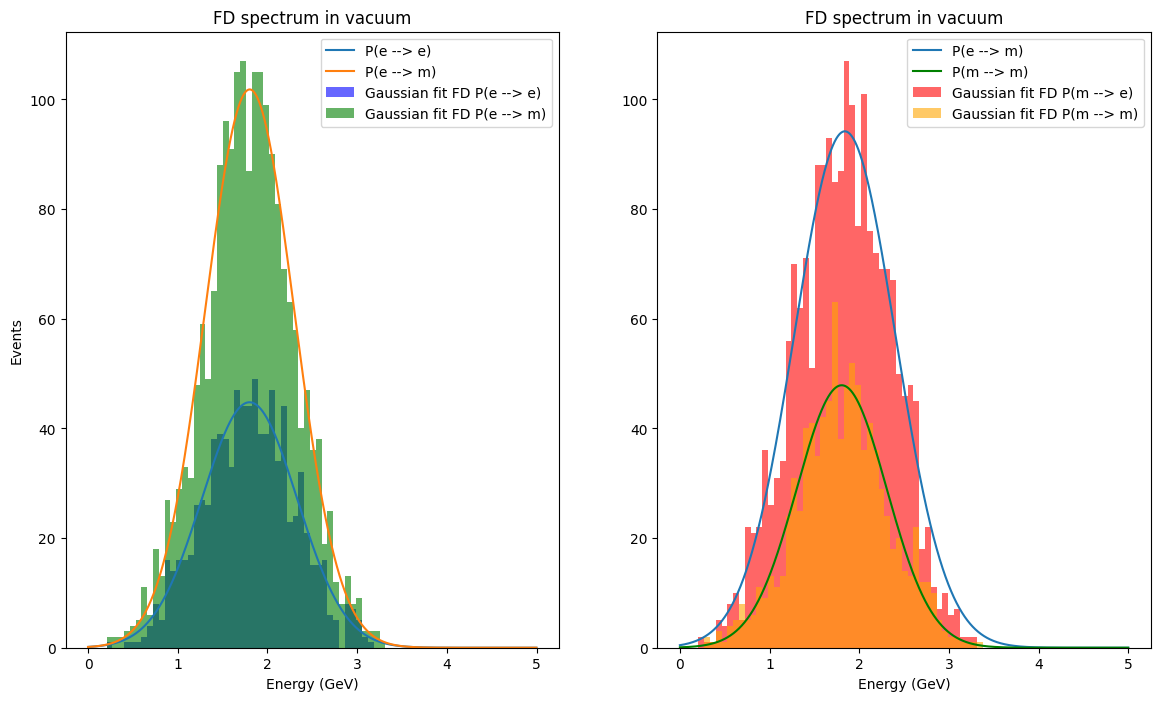

In [8]:
# Calculate oscillation probabilities for each bin center
Pee_vc_fd, Pem_vc_fd, Pme_vc_fd, Pmm_vc_fd = probabilities(h_vacuum, bin_centers,length_fd *5.06773e9)

# Generate event counts for each transition type based on probabilities
counts_Pee_vc_fd = poisson_dist(Pee_vc_fd,bin_centers)
counts_Pem_vc_fd = poisson_dist(Pem_vc_fd,bin_centers)
counts_Pme_vc_fd = poisson_dist(Pme_vc_fd,bin_centers)
counts_Pmm_vc_fd = poisson_dist(Pmm_vc_fd,bin_centers)

# 2x2 grid of subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 8))

# Fit Gaussian curves to each count distribution and print the parameters
initial_guess=[max(counts_Pem_vc_fd),1.8,0.5]
bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])
popt_Pee_fd, _ = curve_fit(gaus, bin_edges[:-1], counts_Pee_vc_fd, p0=initial_guess)
print(f"Fitted parameters for simulated FD P(e --> e) events: Amplitude = {popt_Pee_fd[0]}, Mean = {popt_Pee_fd[1]}, Sigma = {popt_Pee_fd[2]}")

popt_Pem_fd, _ = curve_fit(gaus, bin_edges[:-1], counts_Pem_vc_fd, p0=initial_guess, bounds=bounds)
print(f"Fitted parameters for simulated FD P(e --> m) events: Amplitude = {popt_Pem_fd[0]}, Mean = {popt_Pem_fd[1]}, Sigma = {popt_Pem_fd[2]}")

popt_Pme_fd, _ = curve_fit(gaus, bin_edges[:-1], counts_Pme_vc_fd, p0=initial_guess, bounds=bounds)
print(f"Fitted parameters for simulated FD P(e --> m) events: Amplitude = {popt_Pme_fd[0]}, Mean = {popt_Pme_fd[1]}, Sigma = {popt_Pme_fd[2]}")

popt_Pmm_fd, _ = curve_fit(gaus, bin_edges[:-1], counts_Pmm_vc_fd, p0=initial_guess, bounds=bounds)
print(f"Fitted parameters for simulated FD P(m --> m) events: Amplitude = {popt_Pmm_fd[0]}, Mean = {popt_Pmm_fd[1]}, Sigma = {popt_Pmm_fd[2]}")

# Display histogram of the results
axs[0].hist(bin_edges[:-1], bins=50, weights=counts_Pee_vc_fd, alpha=0.6, color='b')
axs[0].hist(bin_edges[:-1], bins=50, weights=counts_Pem_vc_fd, alpha=0.6, color='g')
axs[0].plot(x,gaus(x,*popt_Pee_fd))
axs[0].plot(x,gaus(x,*popt_Pem_fd))
axs[0].set_title("FD spectrum in vacuum")
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")
axs[0].legend(['P(e --> e)','P(e --> m)','Gaussian fit FD P(e --> e)','Gaussian fit FD P(e --> m)'])

axs[1].hist(bin_edges[:-1], bins=50, weights=counts_Pme_vc_fd, alpha=0.6, color='r')
axs[1].hist(bin_edges[:-1], bins=50, weights=counts_Pmm_vc_fd,alpha=0.6, color='orange')
axs[1].plot(x,gaus(x,*popt_Pme_fd))
axs[1].plot(x,gaus(x,*popt_Pmm_fd), color='g')
axs[1].set_title("FD spectrum in vacuum")
axs[1].set_xlabel("Energy (GeV)")
axs[1].legend(['P(e --> m)', 'P(m --> m)','Gaussian fit FD P(m --> e)','Gaussian fit FD P(m --> m)'])

Fitted parameters for simulated ND P(e --> e) events: Amplitude = 136.5132566767841, Mean = 1.80679850826655, Sigma = 0.5261886508140537
Fitted parameters for simulated ND P(e --> m) events: Amplitude = 3.247118086609162, Mean = 1.757004695550607, Sigma = 0.5567802159163034
Fitted parameters for simulated ND P(e --> m) events: Amplitude = 2.620478438695188, Mean = 1.7444399102737667, Sigma = 0.6052162176534536
Fitted parameters for simulated ND P(m --> m) events: Amplitude = 138.42103303259805, Mean = 1.778802020797357, Sigma = 0.5318050737602847


Parameters of actual data: Amplitude = 143.9478108222235, Mean = 1.8384983482522512, Sigma = 0.5273664472026398 


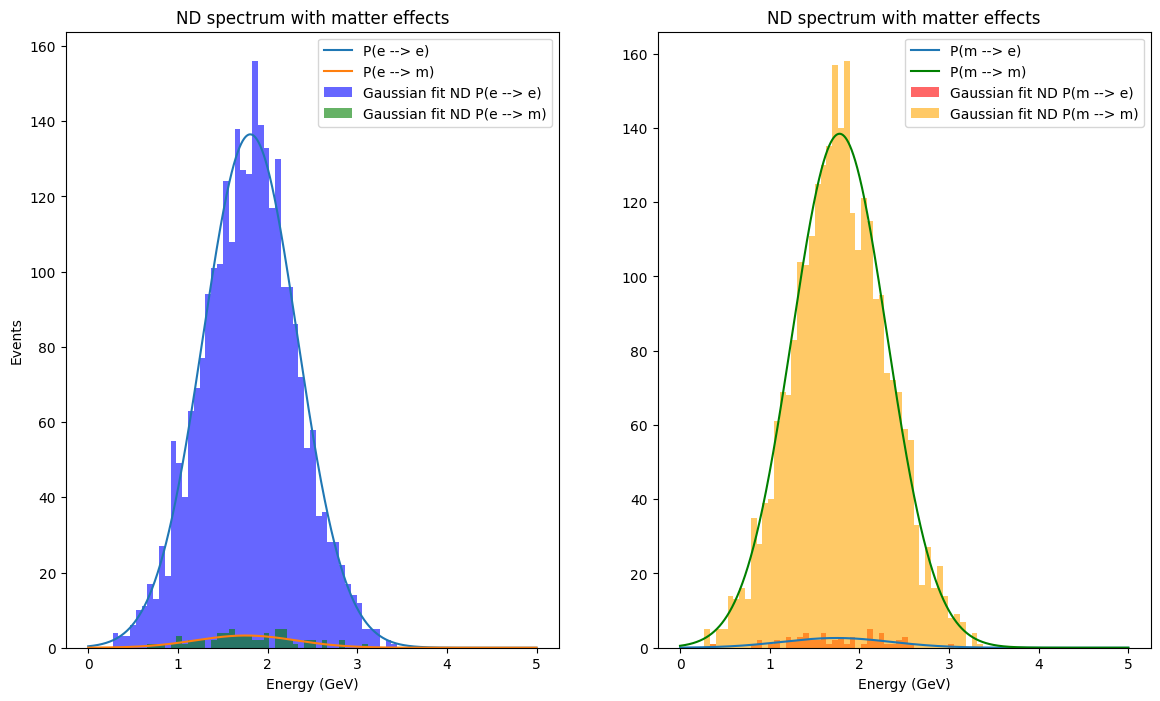

In [9]:
# Calculate oscillation probabilities for each bin center
Pee_matter_nd, Pem_matter_nd, Pme_matter_nd, Pmm_matter_nd = probabilities(h_matter, bin_centers,length_nd *5.06773e9)

# Generate event counts for each transition type based on probabilities
counts_Pee_matter_nd = poisson_dist(Pee_matter_nd,bin_centers)
counts_Pem_matter_nd = poisson_dist(Pem_matter_nd,bin_centers)
counts_Pme_matter_nd = poisson_dist(Pme_matter_nd,bin_centers)
counts_Pmm_matter_nd = poisson_dist(Pmm_matter_nd,bin_centers)

# Set up Gaussian initial guess for curve fitting
x = np.arange(0,5,0.001)
initial_guess = [140,2,0.5]

# Fit Gaussian curves to each count distribution and print the parameters
popt_Pee_nd_matter, _ = curve_fit(gaus, bin_edges[:-1], counts_Pee_matter_nd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(e --> e) events: Amplitude = {popt_Pee_nd_matter[0]}, Mean = {popt_Pee_nd_matter[1]}, Sigma = {popt_Pee_nd_matter[2]}")

popt_Pem_nd_matter, _ = curve_fit(gaus, bin_edges[:-1], counts_Pem_matter_nd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(e --> m) events: Amplitude = {popt_Pem_nd_matter[0]}, Mean = {popt_Pem_nd_matter[1]}, Sigma = {popt_Pem_nd_matter[2]}")

popt_Pme_nd_matter, _ = curve_fit(gaus, bin_edges[:-1], counts_Pme_matter_nd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(e --> m) events: Amplitude = {popt_Pme_nd_matter[0]}, Mean = {popt_Pme_nd_matter[1]}, Sigma = {popt_Pme_nd_matter[2]}")

popt_Pmm_nd_matter, _ = curve_fit(gaus, bin_edges[:-1], counts_Pmm_matter_nd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(m --> m) events: Amplitude = {popt_Pmm_nd_matter[0]}, Mean = {popt_Pmm_nd_matter[1]}, Sigma = {popt_Pmm_nd_matter[2]}")

print('\n')
print(f'Parameters of actual data: Amplitude = {amplitude}, Mean = {mean}, Sigma = {sigma} ')

# 2x2 grid of subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 8))

# Display histogram of the results
axs[0].hist(bin_edges[:-1], bins=50, weights=counts_Pee_matter_nd, density=False, alpha=0.6, color='b')
axs[0].hist(bin_edges[:-1], bins=50, weights=counts_Pem_matter_nd, density=False, alpha=0.6, color='g')
axs[0].plot(x,gaus(x,*popt_Pee_nd_matter))
axs[0].plot(x,gaus(x,*popt_Pem_nd_matter))
axs[0].set_title("ND spectrum with matter effects")
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")
axs[0].legend(['P(e --> e)','P(e --> m)','Gaussian fit ND P(e --> e)','Gaussian fit ND P(e --> m)'])

axs[1].hist(bin_edges[:-1], bins=50, weights=counts_Pme_matter_nd, density=False, alpha=0.6, color='r')
axs[1].hist(bin_edges[:-1], bins=50, weights=counts_Pmm_matter_nd, density=False, alpha=0.6, color='orange')
axs[1].plot(x,gaus(x,*popt_Pme_nd_matter))
axs[1].plot(x,gaus(x,*popt_Pmm_nd_matter), color='g')
axs[1].set_title("ND spectrum with matter effects")
axs[1].set_xlabel("Energy (GeV)")
axs[1].legend(['P(m --> e)', 'P(m --> m)','Gaussian fit ND P(m --> e)','Gaussian fit ND P(m --> m)'])

Fitted parameters for simulated ND P(e --> e) events: Amplitude = 91.9046541009772, Mean = 1.798687382037819, Sigma = 0.5302129698446701
Fitted parameters for simulated ND P(e --> m) events: Amplitude = 46.59861932191338, Mean = 1.8267781253611246, Sigma = 0.5512733401751739
Fitted parameters for simulated ND P(e --> m) events: Amplitude = 48.71918570036687, Mean = 1.8049745276413056, Sigma = 0.5114184229707973
Fitted parameters for simulated ND P(m --> m) events: Amplitude = 97.53024529121622, Mean = 1.819446118093425, Sigma = 0.5227793614237185


Parameters of actual data: Amplitude = 143.9478108222235, Mean = 1.8384983482522512, Sigma = 0.5273664472026398 


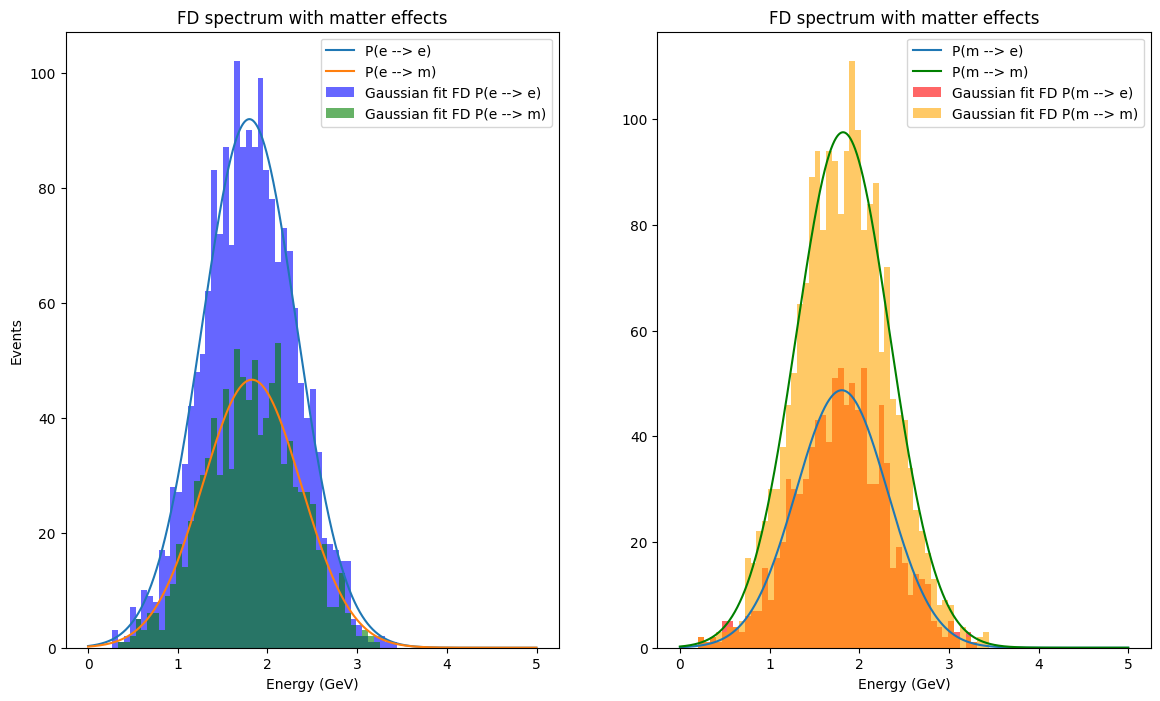

In [10]:
# Calculate oscillation probabilities for each bin center
Pee_matter_fd, Pem_matter_fd, Pme_matter_fd, Pmm_matter_fd = probabilities(h_matter, bin_centers,length_fd *5.06773e9)

# Generate event counts for each transition type based on probabilities
counts_Pee_matter_fd = poisson_dist(Pee_matter_fd,bin_centers)
counts_Pem_matter_fd = poisson_dist(Pem_matter_fd,bin_centers)
counts_Pme_matter_fd = poisson_dist(Pme_matter_fd,bin_centers)
counts_Pmm_matter_fd = poisson_dist(Pmm_matter_fd,bin_centers)

# Set up Gaussian initial guess for curve fitting
x = np.arange(0,5,0.001)
initial_guess = [140,2,0.5]

# Fit Gaussian curves to each count distribution and print the parameters
popt_Pee_fd_matter, _ = curve_fit(gaus, bin_edges[:-1], counts_Pee_matter_fd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(e --> e) events: Amplitude = {popt_Pee_fd_matter[0]}, Mean = {popt_Pee_fd_matter[1]}, Sigma = {popt_Pee_fd_matter[2]}")

popt_Pem_fd_matter, _ = curve_fit(gaus, bin_edges[:-1], counts_Pem_matter_fd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(e --> m) events: Amplitude = {popt_Pem_fd_matter[0]}, Mean = {popt_Pem_fd_matter[1]}, Sigma = {popt_Pem_fd_matter[2]}")

popt_Pme_fd_matter, _ = curve_fit(gaus, bin_edges[:-1], counts_Pme_matter_fd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(e --> m) events: Amplitude = {popt_Pme_fd_matter[0]}, Mean = {popt_Pme_fd_matter[1]}, Sigma = {popt_Pme_fd_matter[2]}")

popt_Pmm_fd_matter, _ = curve_fit(gaus, bin_edges[:-1], counts_Pmm_matter_fd, p0=initial_guess)
print(f"Fitted parameters for simulated ND P(m --> m) events: Amplitude = {popt_Pmm_fd_matter[0]}, Mean = {popt_Pmm_fd_matter[1]}, Sigma = {popt_Pmm_fd_matter[2]}")

print('\n')
print(f'Parameters of actual data: Amplitude = {amplitude}, Mean = {mean}, Sigma = {sigma} ')

# 2x2 grid of subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 8))

# Display histogram of the results
axs[0].hist(bin_edges[:-1], bins=50, weights=counts_Pee_matter_fd, density=False, alpha=0.6, color='b')
axs[0].hist(bin_edges[:-1], bins=50, weights=counts_Pem_matter_fd, density=False, alpha=0.6, color='g')
axs[0].plot(x,gaus(x,*popt_Pee_fd_matter))
axs[0].plot(x,gaus(x,*popt_Pem_fd_matter))
axs[0].set_title("FD spectrum with matter effects")
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")
axs[0].legend(['P(e --> e)','P(e --> m)','Gaussian fit FD P(e --> e)','Gaussian fit FD P(e --> m)'])

axs[1].hist(bin_edges[:-1], bins=50, weights=counts_Pme_matter_fd, density=False, alpha=0.6, color='r')
axs[1].hist(bin_edges[:-1], bins=50, weights=counts_Pmm_matter_fd, density=False, alpha=0.6, color='orange')
axs[1].plot(x,gaus(x,*popt_Pme_fd_matter))
axs[1].plot(x,gaus(x,*popt_Pmm_fd_matter), color='g')
axs[1].set_title("FD spectrum with matter effects")
axs[1].set_xlabel("Energy (GeV)")
axs[1].legend(['P(m --> e)', 'P(m --> m)','Gaussian fit FD P(m --> e)','Gaussian fit FD P(m --> m)'])